# Гипотеза: Рост зарплаты от стажа зависит от специализации

Этот ноутбук проверяет гипотезу:

**Чем больше опыт работы, тем выше ожидаемая зарплата, но форма и сила этой зависимости различаются между специальностями.**

Для проверки используются очищенные данные из `dataset_cleaned.csv`.

In [22]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Загрузка очищенных данных

In [23]:
df = pd.read_csv("dataset_cleaned.csv")

if "date_publish" in df.columns:
    df["date_publish"] = pd.to_datetime(df["date_publish"], errors="coerce")

df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["experience"] = pd.to_numeric(df["experience"], errors="coerce")
df["position_name"] = df["position_name"].fillna("Не указано")

print(df.shape)
df[["position_name", "salary", "experience"]].head()

(43227, 65)


,position_name,salary,experience
0,Оператор,20000,17.0
1,Продавец,20000,0.0
2,Бухгалтер,25000,12.0
3,Водитель погрузчика,30000,0.0
4,Водитель категории в с,35000,3.0


## 2. Рабочая выборка для гипотезы

In [24]:
hyp_df = df[["position_name", "salary", "experience"]].dropna().copy()
hyp_df = hyp_df[(hyp_df["salary"] > 0) & (hyp_df["experience"] >= 0)].copy()

position_counts = hyp_df["position_name"].value_counts()
top_positions = position_counts.head(12).index.tolist()

hyp_df_top = hyp_df[hyp_df["position_name"].isin(top_positions)].copy()

summary = pd.DataFrame({
    "count": hyp_df_top.groupby("position_name").size(),
    "mean_salary": hyp_df_top.groupby("position_name")["salary"].mean(),
    "median_salary": hyp_df_top.groupby("position_name")["salary"].median(),
    "mean_experience": hyp_df_top.groupby("position_name")["experience"].mean(),
}).sort_values("count", ascending=False)
summary.round(2)

,count,mean_salary,median_salary,mean_experience
position_name,,,,
Бухгалтер,2109,24447.50,20000.0,7.74
Специалист,2072,23174.00,20000.0,6.25
Администратор,1196,23515.84,20000.0,5.02
Менеджер,1143,25242.40,20000.0,5.97
Экономист,919,26317.19,25000.0,6.61
Инженер,565,30555.75,26000.0,6.61
Продавец,555,19835.82,18000.0,2.79
Секретарь,543,20755.06,20000.0,4.45
Делопроизводитель,518,20831.39,20000.0,5.66


## 3. Общая зависимость зарплаты от стажа

In [25]:
experience_curve = hyp_df.groupby("experience").agg(
    mean_salary=("salary", "mean"),
    median_salary=("salary", "median"),
    count=("salary", "size"),
).reset_index()

experience_curve = experience_curve[experience_curve["count"] >= 30]
experience_curve.head()

,experience,mean_salary,median_salary,count
0,0.0,23021.032412,20000.0,14223
1,1.0,22894.700611,20000.0,4252
2,2.0,23500.986928,20000.0,2754
3,3.0,24801.122501,20000.0,2351
4,4.0,24749.588977,20000.0,2141


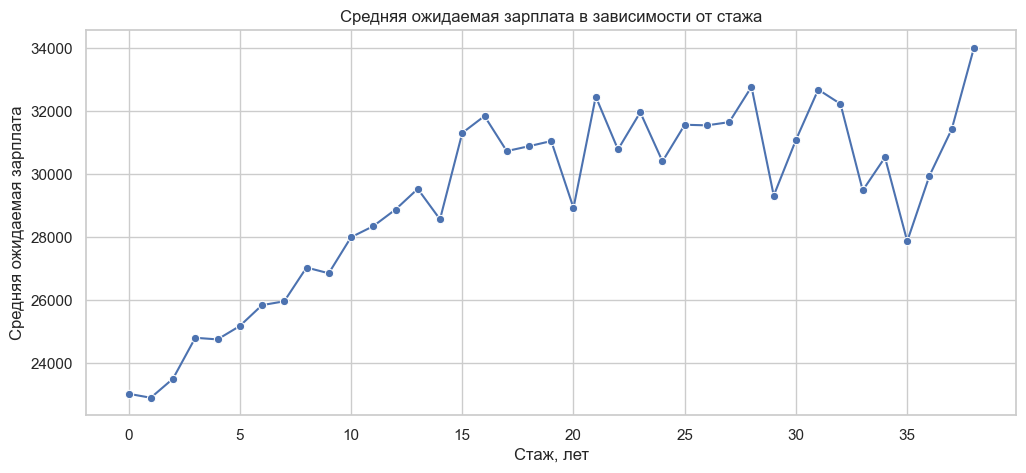

In [26]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=experience_curve, x="experience", y="mean_salary", marker="o")
plt.title("Средняя ожидаемая зарплата в зависимости от стажа")
plt.xlabel("Стаж, лет")
plt.ylabel("Средняя ожидаемая зарплата")
plt.show()

## 4. Средняя зарплата по бакетам стажа и специальностям

In [27]:
hyp_df_top["experience_bucket"] = pd.cut(
    hyp_df_top["experience"],
    bins=[-0.1, 0, 1, 3, 5, 10, 20, 60, 1000],
    labels=["0", "1", "2-3", "4-5", "6-10", "11-20", "21-60", "61+"],
)

bucket_specialty = hyp_df_top.groupby(["position_name", "experience_bucket"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

bucket_specialty = bucket_specialty[bucket_specialty["count"] >= 10]
bucket_specialty.head(20)

,position_name,experience_bucket,mean_salary,count
0,Администратор,0,22975.283920,398
1,Администратор,1,23088.533333,150
2,Администратор,2-3,23338.837209,172
3,Администратор,4-5,23640.350877,114
4,Администратор,6-10,23231.494253,174
5,Администратор,11-20,24831.355932,118
6,Администратор,21-60,26226.257143,70
7,Бухгалтер,0,22270.935961,406
8,Бухгалтер,1,21136.417910,134
9,Бухгалтер,2-3,23407.060302,199


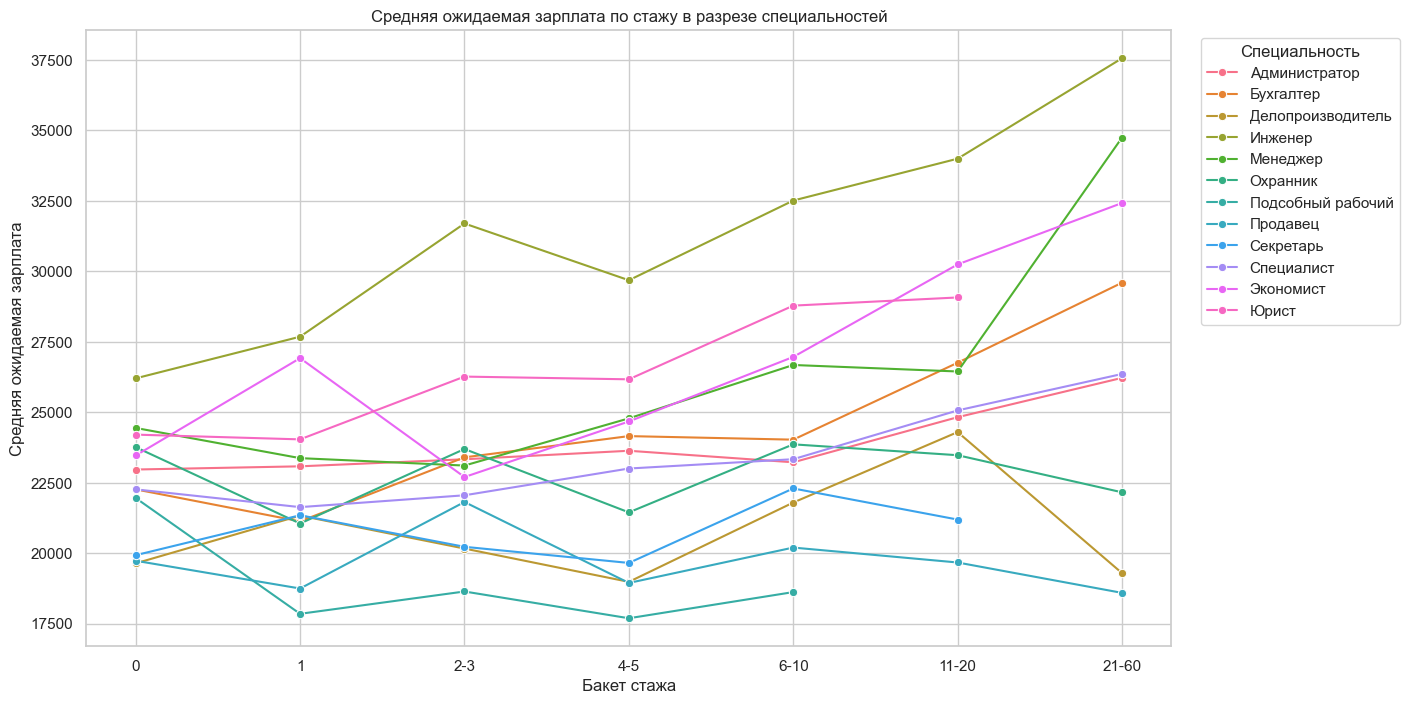

In [28]:
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=bucket_specialty,
    x="experience_bucket",
    y="mean_salary",
    hue="position_name",
    marker="o",
)
plt.title("Средняя ожидаемая зарплата по стажу в разрезе специальностей")
plt.xlabel("Бакет стажа")
plt.ylabel("Средняя ожидаемая зарплата")
plt.legend(title="Специальность", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 5. Матрица графиков: зарплата от стажа по специальностям

In [29]:
specialty_curve = hyp_df_top.groupby(["position_name", "experience"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

specialty_curve = specialty_curve[specialty_curve["count"] >= 10]
specialty_curve.head(20)

,position_name,experience,mean_salary,count
0,Администратор,0.0,22975.283920,398
1,Администратор,1.0,23088.533333,150
2,Администратор,2.0,23654.831461,89
3,Администратор,3.0,23000.000000,83
4,Администратор,4.0,22876.923077,65
5,Администратор,5.0,24653.061224,49
6,Администратор,6.0,21395.833333,48
7,Администратор,7.0,24621.621622,37
8,Администратор,8.0,23665.000000,32
9,Администратор,9.0,22685.714286,35


Text(0.5, 0.98, 'Зависимость средней ожидаемой зарплаты от стажа по специальностям')

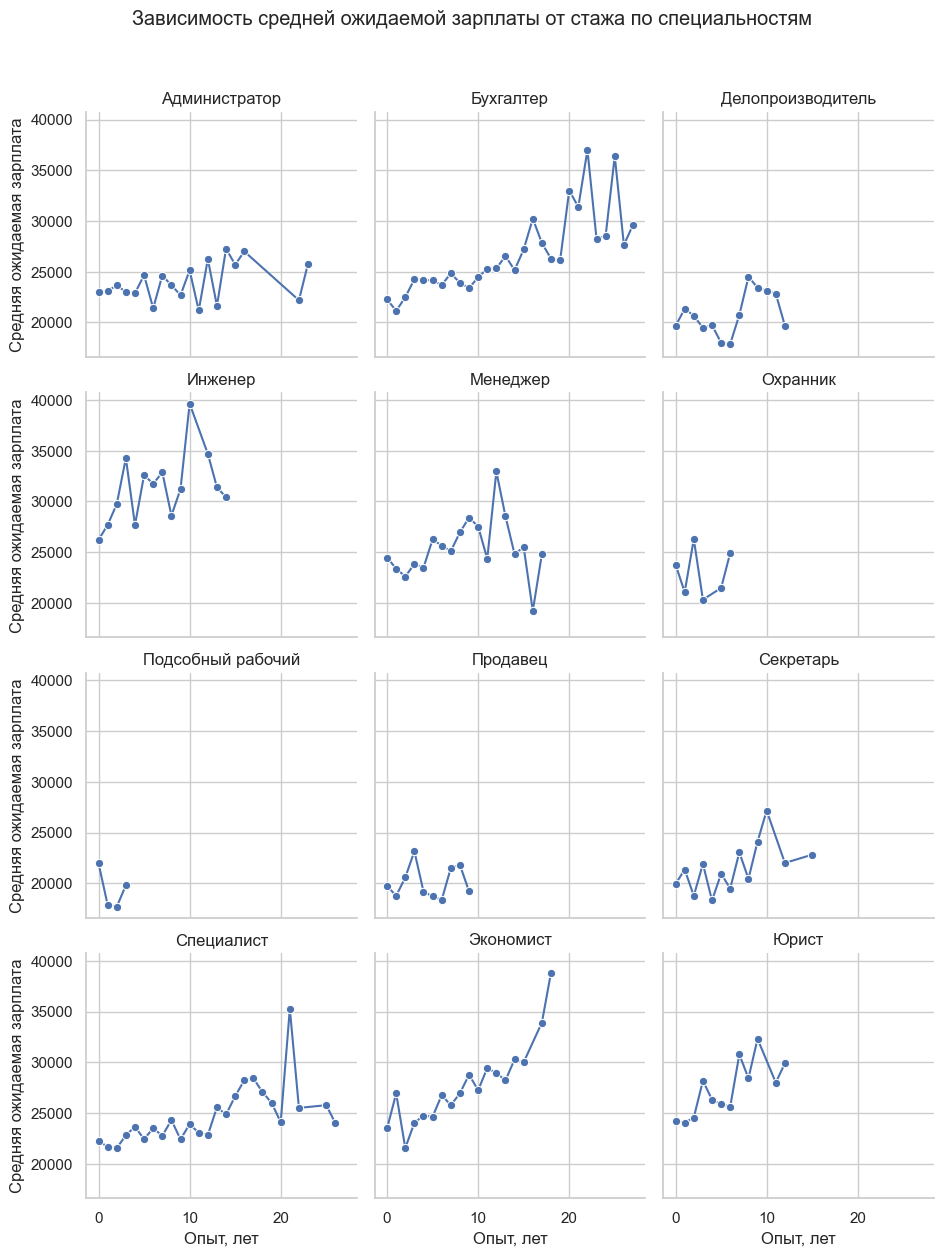

In [30]:
g = sns.FacetGrid(
    specialty_curve,
    col="position_name",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=3.2,
)
g.map_dataframe(sns.lineplot, x="experience", y="mean_salary", marker="o")
g.set_axis_labels("Опыт, лет", "Средняя ожидаемая зарплата")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Зависимость средней ожидаемой зарплаты от стажа по специальностям")

## 6. Тепловая карта: средняя зарплата по специальностям и стажу

In [31]:
heatmap_df = bucket_specialty.pivot(index="position_name", columns="experience_bucket", values="mean_salary")
heatmap_df = heatmap_df.reindex(index=top_positions)
heatmap_df.round(1)

experience_bucket,0,1,2-3,4-5,6-10,11-20,21-60
position_name,,,,,,,
Бухгалтер,22270.9,21136.4,23407.1,24160.3,24034.5,26763.3,29602.1
Специалист,22270.7,21641.5,22061.3,23010.9,23340.7,25071.4,26364.5
Администратор,22975.3,23088.5,23338.8,23640.4,23231.5,24831.4,26226.3
Менеджер,24449.4,23378.6,23115.9,24789.6,26682.9,26452.6,34750.0
Экономист,23473.0,26925.4,22708.3,24679.2,26968.6,30250.0,32428.6
Инженер,26208.9,27686.3,31701.5,29688.5,32515.2,34000.0,37562.5
Продавец,19739.2,18755.1,21823.5,18952.4,20206.9,19677.4,18600.0
Секретарь,19937.1,21352.9,20234.0,19661.8,22303.7,21200.0,NaN
Делопроизводитель,19647.1,21340.0,20171.9,18990.4,21804.1,24302.8,19300.0


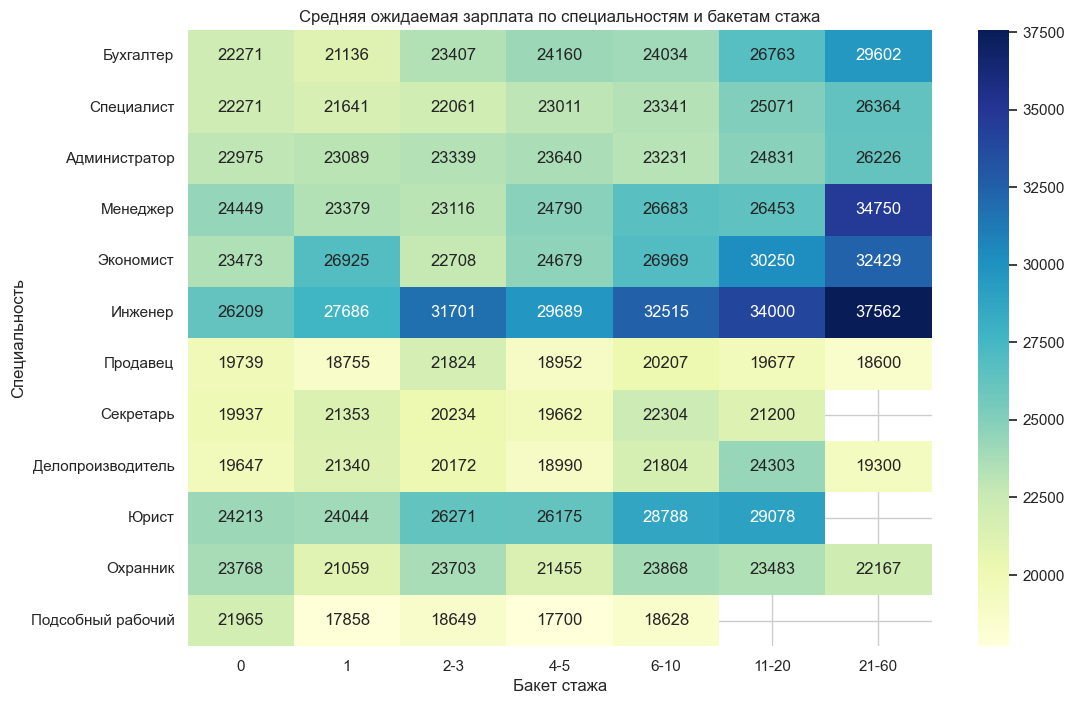

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Средняя ожидаемая зарплата по специальностям и бакетам стажа")
plt.xlabel("Бакет стажа")
plt.ylabel("Специальность")
plt.show()

## 7. Сила связи `зарплата ~ опыт` по специальностям

In [33]:
specialty_corr = (
    hyp_df_top.groupby("position_name")
    .apply(lambda x: x[["salary", "experience"]].corr(method="spearman").loc["salary", "experience"])
    .rename("spearman_salary_experience")
    .reset_index()
    .sort_values("spearman_salary_experience", ascending=False)
)

specialty_corr.round(3)

,position_name,spearman_salary_experience
3,Инженер,0.274
10,Экономист,0.263
1,Бухгалтер,0.231
11,Юрист,0.222
4,Менеджер,0.162
9,Специалист,0.134
2,Делопроизводитель,0.126
8,Секретарь,0.103
0,Администратор,0.065
5,Охранник,0.028


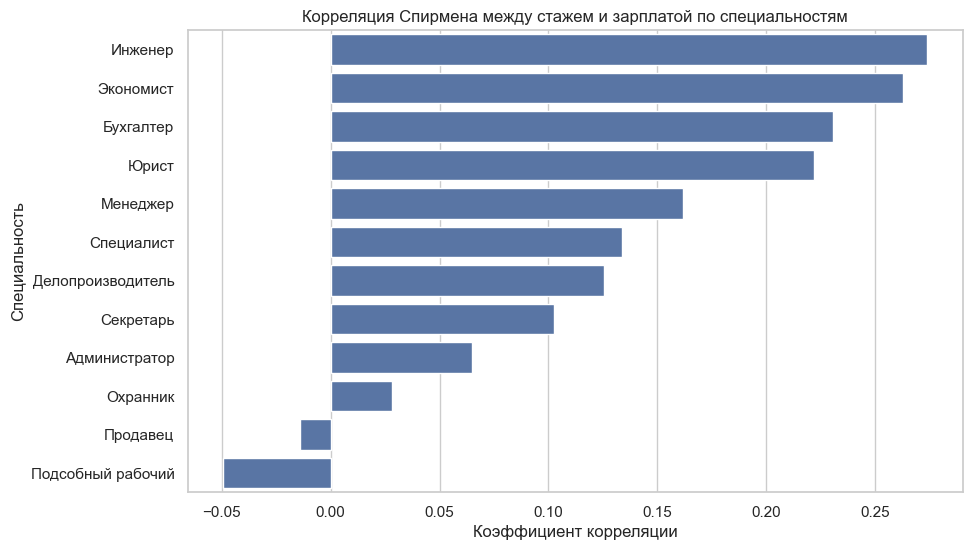

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=specialty_corr, x="spearman_salary_experience", y="position_name", color="#4C72B0")
plt.title("Корреляция Спирмена между стажем и зарплатой по специальностям")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Специальность")
plt.show()

## 8. Регрессионная модель для проверки гипотезы

Построим две нелинейные OLS-модели на усреднённом тренде в реалистичном диапазоне стажа `0–60` лет:
- базовую: `salary ~ experience + experience²`;
- расширенную: `salary ~ experience + experience² + specialization + interactions`.

Сначала данные агрегируются до среднего значения зарплаты для каждой пары `specialization × experience`, затем модель обучается уже на этих усреднённых точках. Квадратичный член нужен, потому что гипотеза допускает разную форму зависимости, а не только разный линейный наклон. Ограничение по стажу до `60` лет убирает явный выброс `1002` года опыта.

In [35]:
reg_df = hyp_df_top[["position_name", "salary", "experience"]].dropna().copy()
reg_df = reg_df[reg_df["experience"].between(0, 60)].copy()

trend_df = reg_df.groupby(["position_name", "experience"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()
trend_df = trend_df[trend_df["count"] >= 10].copy()
trend_df["experience_sq"] = trend_df["experience"] ** 2

X_base = np.column_stack([
    np.ones(len(trend_df)),
    trend_df["experience"].to_numpy(dtype=float),
    trend_df["experience_sq"].to_numpy(dtype=float),
])

position_dummies = pd.get_dummies(trend_df["position_name"], prefix="position", drop_first=True, dtype=float)
interaction_linear = position_dummies.mul(trend_df["experience"], axis=0)
interaction_linear.columns = [f"{col}_x_experience" for col in interaction_linear.columns]
interaction_quadratic = position_dummies.mul(trend_df["experience_sq"], axis=0)
interaction_quadratic.columns = [f"{col}_x_experience_sq" for col in interaction_quadratic.columns]

X_full_df = pd.concat([
    pd.Series(1.0, index=trend_df.index, name="intercept"),
    trend_df[["experience", "experience_sq"]].astype(float),
    position_dummies,
    interaction_linear,
    interaction_quadratic,
], axis=1)

X_full = X_full_df.to_numpy(dtype=float)
y = trend_df["mean_salary"].to_numpy(dtype=float)

coef_base, *_ = np.linalg.lstsq(X_base, y, rcond=None)
coef_full, *_ = np.linalg.lstsq(X_full, y, rcond=None)

pred_base = X_base @ coef_base
pred_full = X_full @ coef_full

sst = ((y - y.mean()) ** 2).sum()
sse_base = ((y - pred_base) ** 2).sum()
sse_full = ((y - pred_full) ** 2).sum()

r2_base = 1 - sse_base / sst
r2_full = 1 - sse_full / sst

n = len(y)
p_base = X_base.shape[1] - 1
p_full = X_full.shape[1] - 1

adj_r2_base = 1 - (1 - r2_base) * (n - 1) / (n - p_base - 1)
adj_r2_full = 1 - (1 - r2_full) * (n - 1) / (n - p_full - 1)

model_metrics = pd.DataFrame({
    "model": [
        "salary ~ experience + experience²",
        "salary ~ experience + experience² + specialization + interactions",
    ],
    "n_obs": [n, n],
    "n_features": [p_base, p_full],
    "R2": [r2_base, r2_full],
    "adjusted_R2": [adj_r2_base, adj_r2_full],
})

trend_df["pred_base"] = pred_base
trend_df["pred_full"] = pred_full

position_r2 = (
    trend_df.groupby("position_name")
    .apply(lambda x: 1 - ((x["mean_salary"] - x["pred_full"]) ** 2).sum() / ((x["mean_salary"] - x["mean_salary"].mean()) ** 2).sum())
    .rename("R2")
    .reset_index()
)
position_r2["facet_title"] = position_r2.apply(lambda x: f"{x['position_name']}\nR²={x['R2']:.3f}", axis=1)

model_metrics.round(4)

,model,n_obs,n_features,R2,adjusted_R2
0,salary ~ experience + experience²,180,2,0.2371,0.2285
1,salary ~ experience + experience² + specializa...,180,35,0.7667,0.7100


По текущей выборке `dataset_cleaned.csv`, после агрегации до среднего тренда `specialization × experience`, получаются следующие значения:
- для модели `salary ~ experience + experience²`: `R² = 0.2371`, `adjusted R² = 0.2285`;
- для модели `salary ~ experience + experience² + specialization + interactions`: `R² = 0.7667`, `adjusted R² = 0.7100`.

Это уже модель именно усреднённого тренда: после снятия индивидуального шума стаж и специализация объясняют заметно большую долю различий в средних зарплатных ожиданиях.

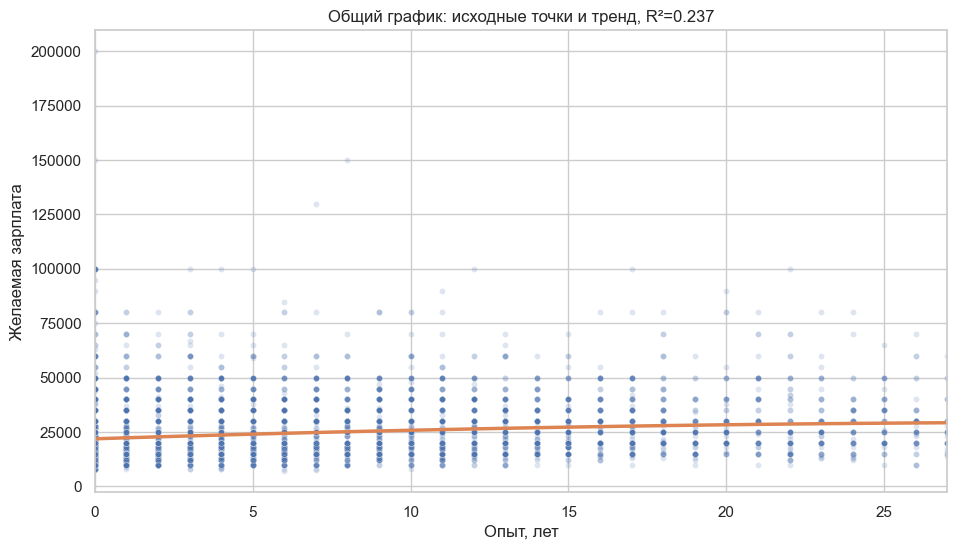

In [36]:
overall_raw_df = reg_df.copy()
overall_trend_df = trend_df.groupby("experience").agg(
    mean_salary=("mean_salary", "mean"),
).reset_index()
overall_trend_df["experience_sq"] = overall_trend_df["experience"] ** 2
overall_trend_df["pred_base"] = np.column_stack([
    np.ones(len(overall_trend_df)),
    overall_trend_df["experience"].to_numpy(dtype=float),
    overall_trend_df["experience_sq"].to_numpy(dtype=float),
]) @ coef_base

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=overall_raw_df,
    x="experience",
    y="salary",
    alpha=0.18,
    s=18,
    color="#4C72B0",
)
plt.plot(overall_trend_df["experience"], overall_trend_df["pred_base"], color="#DD8452", linewidth=2.5)
plt.title(f"Общий график: исходные точки и тренд, R²={r2_base:.3f}")
plt.xlabel("Опыт, лет")
plt.ylabel("Желаемая зарплата")
plt.xlim(0, overall_trend_df["experience"].max())
plt.show()

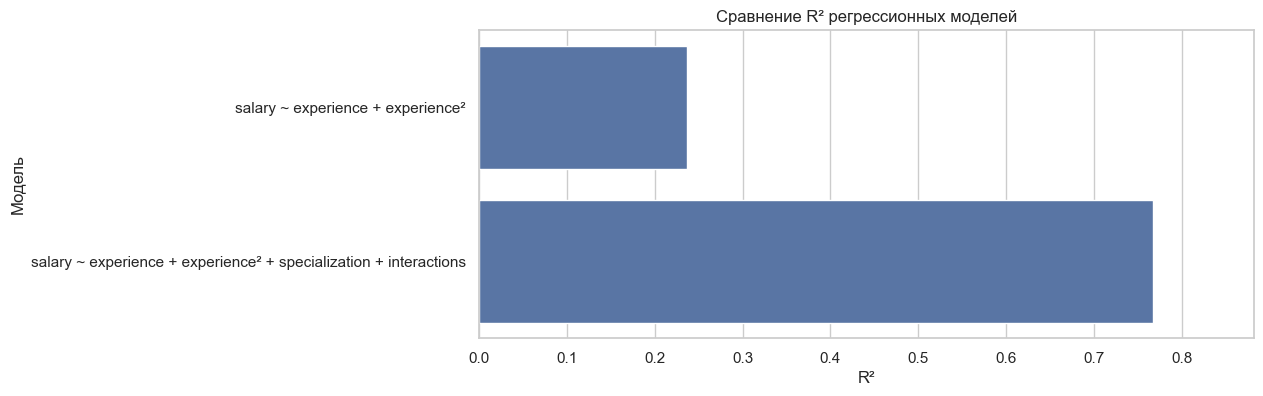

In [37]:
plt.figure(figsize=(10, 4))
sns.barplot(data=model_metrics, x="R2", y="model", color="#4C72B0")
plt.title("Сравнение R² регрессионных моделей")
plt.xlabel("R²")
plt.ylabel("Модель")
plt.xlim(0, model_metrics["R2"].max() * 1.15)
plt.show()

In [38]:
plot_positions = top_positions[:6]
plot_df = reg_df[reg_df["position_name"].isin(plot_positions)].copy()
plot_df = plot_df.merge(position_r2[["position_name", "facet_title"]], on="position_name", how="left")

experience_grid = np.arange(0, int(plot_df["experience"].max()) + 1)
pred_rows = []

for position in plot_positions:
    for exp in experience_grid:
        row = {col: 0.0 for col in X_full_df.columns}
        row["intercept"] = 1.0
        row["experience"] = float(exp)
        row["experience_sq"] = float(exp ** 2)

        dummy_col = f"position_{position}"
        interaction_col = f"position_{position}_x_experience"
        interaction_sq_col = f"position_{position}_x_experience_sq"

        if dummy_col in row:
            row[dummy_col] = 1.0
        if interaction_col in row:
            row[interaction_col] = float(exp)
        if interaction_sq_col in row:
            row[interaction_sq_col] = float(exp ** 2)

        pred_salary = float(np.dot(np.array([row[col] for col in X_full_df.columns]), coef_full))
        pred_rows.append({
            "position_name": position,
            "experience": exp,
            "pred_salary": pred_salary,
        })

pred_df = pd.DataFrame(pred_rows)
pred_df.head()

,position_name,experience,pred_salary
0,Бухгалтер,0,21715.663046
1,Бухгалтер,1,22084.824481
2,Бухгалтер,2,22454.879234
3,Бухгалтер,3,22825.827303
4,Бухгалтер,4,23197.668690


Text(0.5, 0.98, 'Исходные точки и тренд усреднённой модели по специальностям')

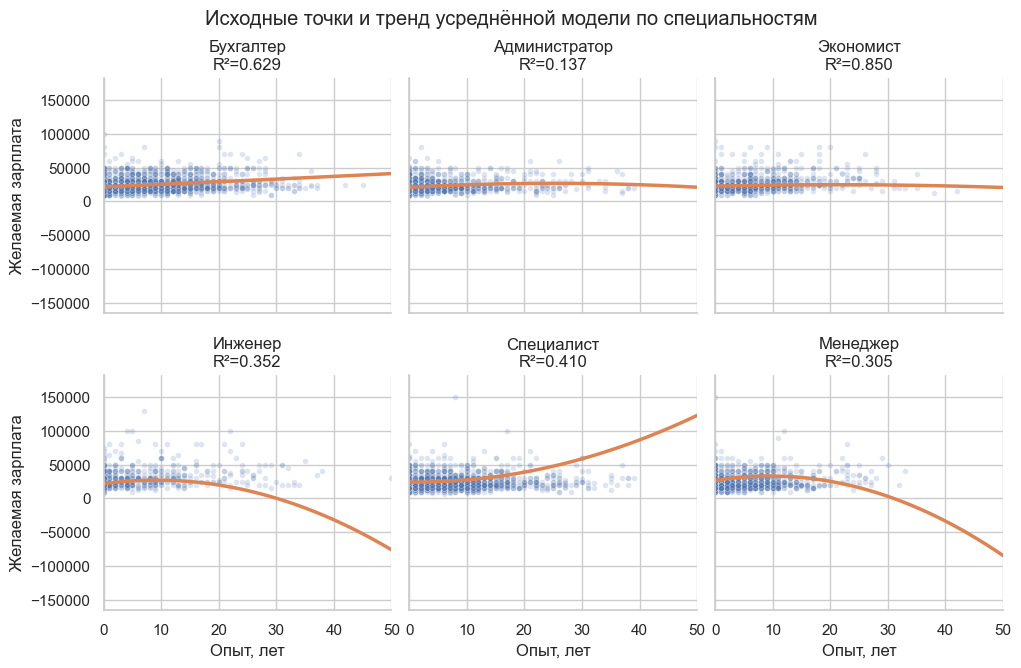

In [39]:
g = sns.FacetGrid(plot_df, col="facet_title", col_wrap=3, height=3.4, sharex=True, sharey=True)
g.map_dataframe(
    sns.scatterplot,
    x="experience",
    y="salary",
    alpha=0.18,
    s=16,
    color="#4C72B0",
)

for ax, position in zip(g.axes.flatten(), plot_positions):
    line_data = pred_df[pred_df["position_name"] == position]
    ax.plot(line_data["experience"], line_data["pred_salary"], color="#DD8452", linewidth=2.5)

g.set_axis_labels("Опыт, лет", "Желаемая зарплата")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.88)

for ax, position in zip(g.axes.flatten(), plot_positions):
    pos_max = int(np.ceil(plot_df.loc[plot_df["position_name"] == position, "experience"].max()))
    ax.set_xlim(0, pos_max)

g.fig.suptitle("Исходные точки и тренд усреднённой модели по специальностям")

In [40]:
coef_full_series = pd.Series(coef_full, index=X_full_df.columns)

specialization_effects = pd.DataFrame({
    "feature": coef_full_series.index,
    "coef": coef_full_series.values,
})

specialization_effects = specialization_effects[
    specialization_effects["feature"].str.contains("position_")
].copy()

specialization_effects["effect_type"] = np.select(
    [
        specialization_effects["feature"].str.contains("_x_experience_sq$"),
        specialization_effects["feature"].str.contains("_x_experience$"),
    ],
    [
        "quadratic_interaction",
        "linear_interaction",
    ],
    default="specialization_intercept_shift",
)

specialization_effects["specialization"] = (
    specialization_effects["feature"]
    .str.replace("position_", "", regex=False)
    .str.replace("_x_experience_sq", "", regex=False)
    .str.replace("_x_experience", "", regex=False)
)

specialization_effects = specialization_effects[["specialization", "effect_type", "coef"]]
specialization_effects.sort_values(["effect_type", "coef"], ascending=[True, False]).round(2).head(20)

,specialization,effect_type,coef
16,Инженер,linear_interaction,1161.20
17,Менеджер,linear_interaction,935.31
24,Юрист,linear_interaction,761.05
22,Специалист,linear_interaction,264.29
21,Секретарь,linear_interaction,241.75
14,Бухгалтер,linear_interaction,161.71
20,Продавец,linear_interaction,-53.04
15,Делопроизводитель,linear_interaction,-147.67
23,Экономист,linear_interaction,-303.61
18,Охранник,linear_interaction,-1373.30


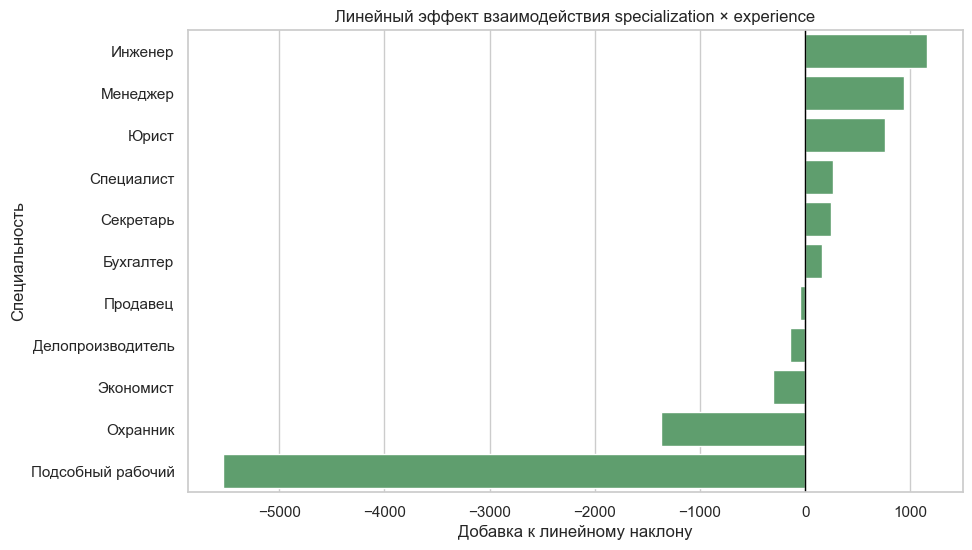

In [41]:
interaction_plot = specialization_effects[
    specialization_effects["effect_type"] == "linear_interaction"
].copy()
interaction_plot = interaction_plot.sort_values("coef", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=interaction_plot, x="coef", y="specialization", color="#55A868")
plt.title("Линейный эффект взаимодействия specialization × experience")
plt.xlabel("Добавка к линейному наклону")
plt.ylabel("Специальность")
plt.axvline(0, color="black", linewidth=1)
plt.show()

## 9. Проверка гипотезы статистическим тестом

Проверим нулевую гипотезу: **ожидаемая зарплата никак не зависит от стажа**.

Сначала разобьём сотрудников по стажу на **3 равные по численности категории без пропусков**. Чтобы категории точно были равными, используем `pd.qcut` не по самим значениям стажа, а по рангу `experience.rank(method="first")`.

После этого сравним средние зарплаты между тремя группами с помощью **однофакторного дисперсионного анализа (ANOVA)**. Так как в окружении нет `scipy`, `F`-статистику считаем вручную, а `p-value` получаем permutation-методом по перестановке меток групп.

In [42]:
anova_df = reg_df[["salary", "experience"]].dropna().copy()
anova_df["experience_group"] = pd.qcut(
    anova_df["experience"].rank(method="first"),
    q=3,
    labels=["low", "mid", "high"],
)

group_stats = anova_df.groupby("experience_group", observed=False).agg(
    min_experience=("experience", "min"),
    max_experience=("experience", "max"),
    median_experience=("experience", "median"),
    count=("salary", "size"),
    mean_salary=("salary", "mean"),
    median_salary=("salary", "median"),
)

def anova_f(groups):
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)
    df_between = len(groups) - 1
    df_within = len(all_values) - len(groups)
    ms_between = ss_between / df_between
    ms_within = ss_within / df_within
    return ms_between / ms_within, df_between, df_within

groups = [g["salary"].to_numpy(dtype=float) for _, g in anova_df.groupby("experience_group", observed=False)]
obs_F, df_between, df_within = anova_f(groups)

rng = np.random.default_rng(42)
labels = anova_df["experience_group"].to_numpy()
salaries = anova_df["salary"].to_numpy(dtype=float)
n_permutations = 5000
extreme_count = 0

for _ in range(n_permutations):
    perm_labels = rng.permutation(labels)
    perm_groups = [salaries[perm_labels == lab] for lab in ["low", "mid", "high"]]
    perm_F, _, _ = anova_f(perm_groups)
    if perm_F >= obs_F:
        extreme_count += 1

perm_p_value = (extreme_count + 1) / (n_permutations + 1)

anova_summary = pd.DataFrame({
    "metric": [
        "n_observations",
        "anova_F_statistic",
        "anova_df_between",
        "anova_df_within",
        "anova_permutation_p_value",
    ],
    "value": [
        len(anova_df),
        obs_F,
        df_between,
        df_within,
        perm_p_value,
    ],
})

display(group_stats.round(2))
anova_summary.round(4)

,min_experience,max_experience,median_experience,count,mean_salary,median_salary
experience_group,,,,,,
low,0.0,1.0,0.0,3595,22610.70,20000.0
mid,1.0,7.0,3.0,3595,23195.95,20000.0
high,7.0,60.0,11.0,3595,26166.68,25000.0


,metric,value
0,n_observations,10785.0000
1,anova_F_statistic,110.4069
2,anova_df_between,2.0000
3,anova_df_within,10782.0000
4,anova_permutation_p_value,0.0002


После разбиения стажа на 3 равные категории без пропусков получили группы по `3595` человек:
- `low`: стаж от `0` до `1` года;
- `mid`: стаж от `1` до `7` лет;
- `high`: стаж от `7` до `60` лет.

Средние зарплаты по группам составили примерно `22610.7`, `23195.9` и `26166.7` рублей соответственно.

Результат ANOVA:
- `F = 110.4069`;
- `df_between = 2`;
- `df_within = 10782`;
- permutation `p-value = 0.0002`.

Следовательно, нулевая гипотеза **отвергается**: ожидаемая зарплата статистически значимо различается между тремя категориями стажа, а значит, не является независимой от стажа.

### Дополнительная проверка: Welch t-test для `low` и `mid`

Проверим более узкую гипотезу для двух групп:
- `H0`: средние зарплатные ожидания в группах `low` и `mid` равны;
- `H1`: средняя ожидаемая зарплата в группе `mid` **больше**, чем в группе `low`.

Используем двухвыборочный t-тест Уэлча. Так как `scipy` недоступен, `t`-статистику и число степеней свободы считаем вручную, а односторонний `p-value` оцениваем через нормальную аппроксимацию. Здесь это допустимо, потому что `df` получается очень большим.

In [43]:
low_salary = anova_df.loc[anova_df["experience_group"] == "low", "salary"].to_numpy(dtype=float)
mid_salary = anova_df.loc[anova_df["experience_group"] == "mid", "salary"].to_numpy(dtype=float)

low_n = len(low_salary)
mid_n = len(mid_salary)
low_mean = low_salary.mean()
mid_mean = mid_salary.mean()
low_var = low_salary.var(ddof=1)
mid_var = mid_salary.var(ddof=1)

welch_se = np.sqrt(low_var / low_n + mid_var / mid_n)
welch_t = (mid_mean - low_mean) / welch_se
welch_df = (low_var / low_n + mid_var / mid_n) ** 2 / (
    ((low_var / low_n) ** 2) / (low_n - 1) + ((mid_var / mid_n) ** 2) / (mid_n - 1)
)

welch_p_value = 0.5 * math.erfc(welch_t / np.sqrt(2))

welch_summary = pd.DataFrame({
    "metric": [
        "low_n",
        "mid_n",
        "low_mean_salary",
        "mid_mean_salary",
        "mean_diff_mid_minus_low",
        "welch_t_statistic",
        "welch_df",
        "welch_one_sided_p_value",
    ],
    "value": [
        low_n,
        mid_n,
        low_mean,
        mid_mean,
        mid_mean - low_mean,
        welch_t,
        welch_df,
        welch_p_value,
    ],
})

welch_summary.round(4)

,metric,value
0,low_n,3595.0000
1,mid_n,3595.0000
2,low_mean_salary,22610.7049
3,mid_mean_salary,23195.9460
4,mean_diff_mid_minus_low,585.2412
5,welch_t_statistic,2.3428
6,welch_df,7077.7680
7,welch_one_sided_p_value,0.0096


Результат Welch t-test для `mid > low`:
- `mean(low) = 22610.70`;
- `mean(mid) = 23195.95`;
- разница средних `mid - low = 585.24`;
- `t = 2.3428`;
- `df ≈ 7077.77`;
- односторонний `p-value ≈ 0.0096`.

Следовательно, нулевая гипотеза о равенстве средних для групп `low` и `mid` **отвергается** на уровне значимости `0.05`: зарплатные ожидания в группе `mid` статистически значимо выше, чем в группе `low`.

## 10. Интерпретация гипотезы

Гипотеза подтверждается, если по графикам видно следующее:
- в среднем зарплата растёт с опытом;
- линии для разных специальностей заметно отличаются по наклону или форме;
- тепловая карта показывает неодинаковый рост по бакетам стажа;
- коэффициенты корреляции `salary ~ experience` различаются между специальностями;
- `R²` расширенной регрессионной модели выше, чем у модели только с опытом.

Если в расширенной модели специализация и взаимодействие `experience:specialization` повышают `R²`, это означает, что одна и та же прибавка в опыте по-разному связана с зарплатными ожиданиями в разных специальностях. Это и является формальной проверкой гипотезы.